In [1]:
import torch

In [4]:
B = 1
LEN = 5
D = 4
N_HEADS = 2

x = torch.randn((B, LEN, D))
x

tensor([[[-1.0129,  1.0952, -0.2131, -0.3580],
         [-1.5906, -2.9685, -2.7210,  0.0762],
         [-0.3151,  0.1145, -1.0522, -0.1037],
         [ 1.8152, -0.1150, -0.7146,  0.4507],
         [-0.0303, -0.6960,  0.2302,  0.6117]]])

In [3]:
Wq = torch.randn((D, D))
Wk = torch.randn((D, D))
Wv = torch.randn((D, D))
Wo = torch.randn((D, D))

In [5]:
HEAD_DIM = D // N_HEADS
HEAD_DIM

2

In [6]:
q = x @ Wq
k = x @ Wk
v = x @ Wv
q

tensor([[[-2.3502,  1.8364, -0.3397, -0.6011],
         [ 4.9633,  1.9130,  1.8899, -4.5148],
         [-0.4192,  0.7255,  0.5621,  0.4840],
         [ 0.4404, -2.6300,  0.9496,  4.5437],
         [ 0.8460, -1.0822,  0.0136, -0.7794]]])

In [9]:
q_head = q.reshape((B, LEN, N_HEADS, HEAD_DIM)).transpose(1, 2)
k_head = k.reshape((B, LEN, N_HEADS, HEAD_DIM)).transpose(1, 2)
v_head = v.reshape((B, LEN, N_HEADS, HEAD_DIM)).transpose(1, 2)
q_head.shape

torch.Size([1, 2, 5, 2])

In [11]:
scores = q_head @ k_head.transpose(-2, -1) / (q_head.shape[-1]**0.5)
score_norm = torch.softmax(scores, dim=-1)
score_norm

tensor([[[[4.8516e-05, 9.9970e-01, 2.0866e-04, 5.1165e-06, 4.2659e-05],
          [6.4903e-07, 9.8377e-01, 1.5488e-04, 1.5717e-02, 3.6098e-04],
          [1.3916e-02, 9.1953e-01, 3.2494e-02, 1.3450e-02, 2.0609e-02],
          [7.6630e-01, 1.0976e-07, 1.9909e-02, 1.4170e-01, 7.2092e-02],
          [2.8426e-01, 6.1503e-04, 9.0253e-02, 4.3310e-01, 1.9177e-01]],

         [[1.6773e-01, 4.5612e-01, 1.7143e-01, 8.5870e-02, 1.1885e-01],
          [3.2466e-03, 8.2033e-01, 3.5469e-02, 1.3202e-01, 8.9376e-03],
          [1.3850e-01, 5.4410e-02, 1.5727e-01, 4.1887e-01, 2.3095e-01],
          [8.6477e-02, 9.2535e-05, 3.2566e-02, 5.6597e-01, 3.1490e-01],
          [1.3833e-01, 4.1329e-01, 1.7869e-01, 1.4181e-01, 1.2787e-01]]]])

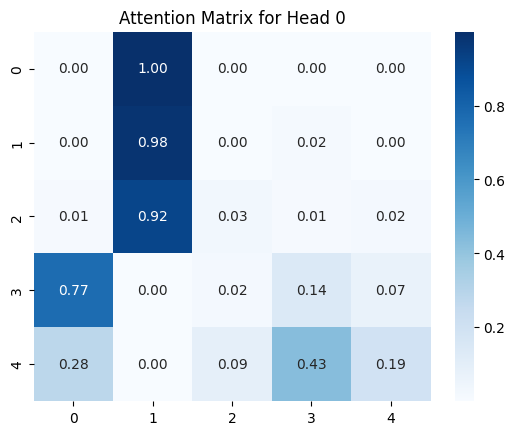

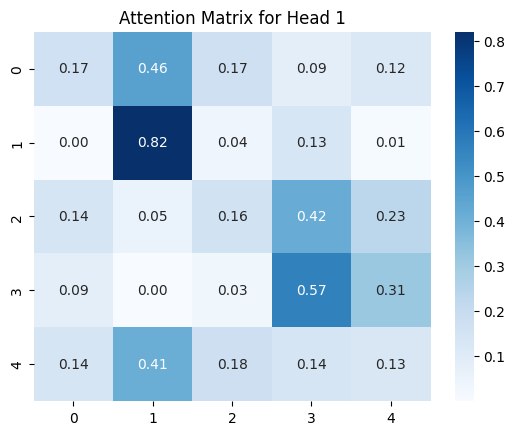

In [13]:
# faz um heatmap da matriz de atenção, um para cada head
import matplotlib.pyplot as plt
import seaborn as sns

att_matrices = score_norm.squeeze(0).detach().numpy()
for i, matrix in enumerate(att_matrices):
    sns.heatmap(matrix, annot=True, cmap="Blues", fmt=".2f")
    plt.title(f"Attention Matrix for Head {i}")
    plt.show()

In [14]:
att = score_norm @ v_head
print(att.shape)
att

torch.Size([1, 2, 5, 2])


tensor([[[[ 0.9525, -3.8760],
          [ 0.8921, -3.8389],
          [ 0.8254, -3.5984],
          [-0.3680,  0.5302],
          [-1.1449, -0.4708]],

         [[ 1.4866, -1.4786],
          [ 2.1044, -1.7602],
          [ 0.1656,  0.6815],
          [-0.1802,  1.6309],
          [ 1.3102, -1.1363]]]])

In [16]:
att = att.transpose(1, 2).contiguous().view((B, LEN, D))
# att = att.transpose(1, 2).reshape((B, LEN, D))
print(att.shape)

torch.Size([1, 5, 4])


In [17]:
att_out = att @ Wo
print(att_out.shape)
att_out

torch.Size([1, 5, 4])


tensor([[[ 2.8872, -2.6248,  3.7463,  6.6851],
         [ 1.8390, -2.4013,  3.5331,  6.6706],
         [ 5.0226, -1.1073,  3.5037,  5.3263],
         [ 0.0393,  2.0588, -0.7970, -1.7263],
         [-0.0901,  0.0543,  0.6238,  0.3484]]])

## MASKED

In [22]:
mask =  torch.tril((torch.ones((LEN, LEN)))).unsqueeze(0).unsqueeze(0).repeat(B, 1, 1, 1)
print(mask.shape)
mask

torch.Size([1, 1, 5, 5])


tensor([[[[1., 0., 0., 0., 0.],
          [1., 1., 0., 0., 0.],
          [1., 1., 1., 0., 0.],
          [1., 1., 1., 1., 0.],
          [1., 1., 1., 1., 1.]]]])

In [23]:
masked_scores = scores.masked_fill(mask == 0, float('-inf'))
masked_scores

tensor([[[[ 7.4697e-01,        -inf,        -inf,        -inf,        -inf],
          [-5.2283e+00,  9.0031e+00,        -inf,        -inf,        -inf],
          [-1.1759e-01,  4.0732e+00,  7.3044e-01,        -inf,        -inf],
          [ 1.3010e+00, -1.4458e+01, -2.3494e+00, -3.8687e-01,        -inf],
          [-3.3968e-03, -6.1394e+00, -1.1507e+00,  4.1767e-01, -3.9700e-01]],

         [[ 1.7836e-01,        -inf,        -inf,        -inf,        -inf],
          [-1.0146e+00,  4.5175e+00,        -inf,        -inf,        -inf],
          [-2.9661e-01, -1.2309e+00, -1.6949e-01,        -inf,        -inf],
          [-4.9050e-01, -7.3305e+00, -1.4671e+00,  1.3882e+00,        -inf],
          [-9.4073e-03,  1.0851e+00,  2.4658e-01,  1.5381e-02, -8.8034e-02]]]])

In [25]:
masked_scores_norm = torch.softmax(masked_scores, dim=-1)
masked_scores_norm

tensor([[[[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [6.5974e-07, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [1.4406e-02, 9.5195e-01, 3.3640e-02, 0.0000e+00, 0.0000e+00],
          [8.2584e-01, 1.1829e-07, 2.1456e-02, 1.5271e-01, 0.0000e+00],
          [2.8426e-01, 6.1503e-04, 9.0253e-02, 4.3310e-01, 1.9177e-01]],

         [[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [3.9421e-03, 9.9606e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [3.9550e-01, 1.5538e-01, 4.4912e-01, 0.0000e+00, 0.0000e+00],
          [1.2622e-01, 1.3507e-04, 4.7535e-02, 8.2611e-01, 0.0000e+00],
          [1.3833e-01, 4.1329e-01, 1.7869e-01, 1.4181e-01, 1.2787e-01]]]])

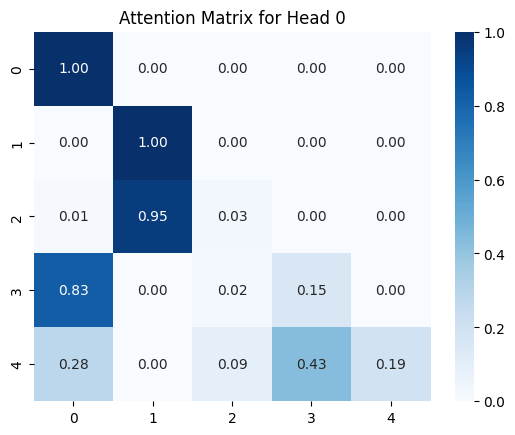

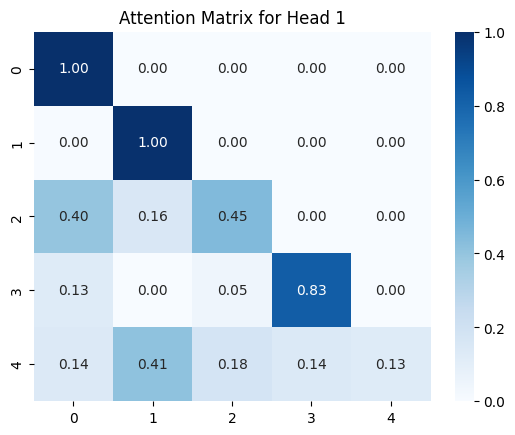

In [26]:
att_matrices = masked_scores_norm.squeeze(0).detach().numpy()
for i, matrix in enumerate(att_matrices):
    sns.heatmap(matrix, annot=True, cmap="Blues", fmt=".2f")
    plt.title(f"Attention Matrix for Head {i}")
    plt.show()

In [29]:
att_masked = masked_scores_norm @ v_head
att_masked

tensor([[[[-0.0208,  1.0042],
          [ 0.9530, -3.8771],
          [ 0.8709, -3.7029],
          [-0.4839,  0.5735],
          [-1.1449, -0.4708]],

         [[ 0.8095, -2.6909],
          [ 2.6604, -2.5335],
          [ 1.0557, -2.0824],
          [-0.6058,  1.8841],
          [ 1.3102, -1.1363]]]])

In [31]:
att_masked = att_masked.transpose(1, 2).contiguous().view((B, LEN, D))
att_masked

tensor([[[-0.0208,  1.0042,  0.8095, -2.6909],
         [ 0.9530, -3.8771,  2.6604, -2.5335],
         [ 0.8709, -3.7029,  1.0557, -2.0824],
         [-0.4839,  0.5735, -0.6058,  1.8841],
         [-1.1449, -0.4708,  1.3102, -1.1363]]])

In [32]:
att_masked_out = att_masked @ Wo
att_masked_out

tensor([[[-3.3914, -1.8643, -0.7909, -0.2739],
         [ 0.8123, -2.8568,  3.5117,  7.0727],
         [ 3.3250, -3.5231,  3.9106,  6.7007],
         [ 0.8436,  2.0681, -0.6902, -1.9426],
         [-0.0901,  0.0543,  0.6238,  0.3484]]])

# CROSS ATTENTION

In [33]:
y = torch.randn((B, 6, 4))

In [34]:
k_y = y @ Wk
v_y = y @ Wv
k_y

tensor([[[ 0.1460, -0.5275, -0.6361, -0.2619],
         [-0.0551,  3.0638, -2.4505, -1.4278],
         [ 0.2937, -0.7470, -1.7992, -0.3208],
         [-0.5244,  0.9027, -1.7982, -0.8186],
         [-1.1219, -1.9305, -1.1427,  0.5057],
         [ 1.5647, -1.1854, -2.0546, -0.5537]]])

In [36]:
k_y_head = k_y.reshape((B, 6, N_HEADS, HEAD_DIM)).transpose(1, 2)
v_y_head = v_y.reshape((B, 6, N_HEADS, HEAD_DIM)).transpose(1, 2)
k_y_head

tensor([[[[ 0.1460, -0.5275],
          [-0.0551,  3.0638],
          [ 0.2937, -0.7470],
          [-0.5244,  0.9027],
          [-1.1219, -1.9305],
          [ 1.5647, -1.1854]],

         [[-0.6361, -0.2619],
          [-2.4505, -1.4278],
          [-1.7992, -0.3208],
          [-1.7982, -0.8186],
          [-1.1427,  0.5057],
          [-2.0546, -0.5537]]]])

In [37]:
scores = q_head @ k_y_head.transpose(-2, -1) / (q_head.shape[-1]**0.5)
scores

tensor([[[[-0.9275,  4.0702, -1.4581,  2.0436, -0.6424, -4.1396],
          [-0.2012,  3.9509,  0.0205, -0.6192, -6.5489,  3.8880],
          [-0.3138,  1.5880, -0.4702,  0.6185, -0.6577, -1.0719],
          [ 1.0264, -5.7150,  1.4806, -1.8420,  3.2408,  2.6918],
          [ 0.4910, -2.3775,  0.7473, -1.0044,  0.8061,  1.8431]],

         [[ 0.2641,  1.1955,  0.5685,  0.7798,  0.0595,  0.7289],
          [-0.0141,  1.2836, -1.3802,  0.2102, -3.1415, -0.9780],
          [-0.3425, -1.4627, -0.8250, -0.9949, -0.2812, -1.0062],
          [-1.2685, -6.2327, -2.2388, -3.8373,  0.8574, -3.1586],
          [ 0.1382,  0.7633,  0.1595,  0.4338, -0.2897,  0.2854]]]])

In [39]:
scores_norm = torch.softmax(scores, dim=-1)
scores_norm

tensor([[[[5.8633e-03, 8.6823e-01, 3.4492e-03, 1.1442e-01, 7.7979e-03,
           2.3613e-04],
          [7.9262e-03, 5.0384e-01, 9.8928e-03, 5.2181e-03, 1.3877e-05,
           4.7311e-01],
          [8.1489e-02, 5.4584e-01, 6.9691e-02, 2.0702e-01, 5.7776e-02,
           3.8184e-02],
          [5.8561e-02, 6.9161e-05, 9.2229e-02, 3.3255e-03, 5.3616e-01,
           3.0966e-01],
          [1.2805e-01, 7.2717e-03, 1.6547e-01, 2.8704e-02, 1.7549e-01,
           4.9501e-01]],

         [[1.1142e-01, 2.8277e-01, 1.5106e-01, 1.8661e-01, 9.0805e-02,
           1.7733e-01],
          [1.5169e-01, 5.5529e-01, 3.8695e-02, 1.8982e-01, 6.6487e-03,
           5.7852e-02],
          [2.4738e-01, 8.0699e-02, 1.5269e-01, 1.2883e-01, 2.6302e-01,
           1.2738e-01],
          [1.0006e-01, 6.9873e-04, 3.7918e-02, 7.6667e-03, 8.3854e-01,
           1.5115e-02],
          [1.4196e-01, 2.6524e-01, 1.4501e-01, 1.9078e-01, 9.2542e-02,
           1.6447e-01]]]])

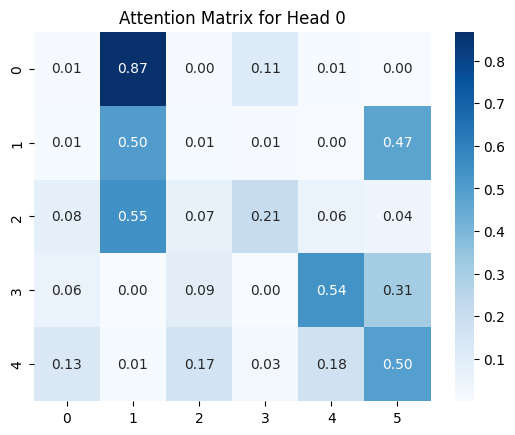

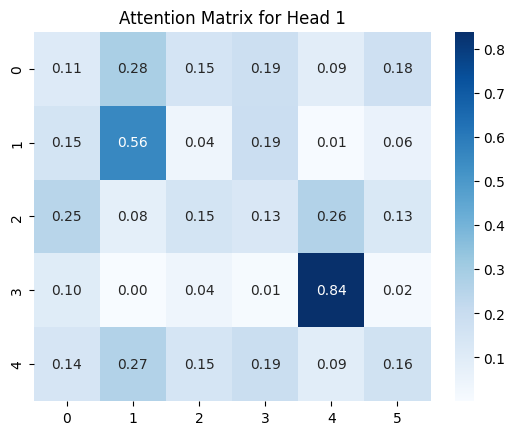

In [40]:
att_matrices = scores_norm.squeeze(0).detach().numpy()
for i, matrix in enumerate(att_matrices):
    sns.heatmap(matrix, annot=True, cmap="Blues", fmt=".2f")
    plt.title(f"Attention Matrix for Head {i}")
    plt.show()

In [41]:
att_cross = scores_norm @ v_y_head
att_cross

tensor([[[[-0.0718, -1.5900],
          [-0.5141, -1.1243],
          [-0.1040, -0.9559],
          [ 0.8900,  1.0677],
          [-0.2157,  0.1627]],

         [[-1.5895, -1.8965],
          [-1.0997, -2.5120],
          [-1.2056, -1.5308],
          [ 0.3289, -1.6438],
          [-1.5398, -1.8825]]]])

In [42]:
att_cross = att_cross.transpose(1, 2).contiguous().view((B, LEN, D))
att_cross

tensor([[[-0.0718, -1.5900, -1.5895, -1.8965],
         [-0.5141, -1.1243, -1.0997, -2.5120],
         [-0.1040, -0.9559, -1.2056, -1.5308],
         [ 0.8900,  1.0677,  0.3289, -1.6438],
         [-0.2157,  0.1627, -1.5398, -1.8825]]])

In [51]:
att_cross = att_cross @ Wo
att_cross

tensor([[[ 5.2308, -4.0637,  2.9337,  3.2265],
         [ 4.0805, -3.9549,  2.5035,  2.5214],
         [ 3.5841, -3.0492,  1.9854,  2.1019],
         [-3.6935, -1.4434, -1.2131, -0.2218],
         [ 2.2950, -3.1462,  1.0029,  0.6274]]])

In [43]:
import torch.nn as nn

class QKVAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, q, k, v, mask=None, return_att_matrix=False):
        scores = q @ k.transpose(-2, -1) / (q.shape[-1]**0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        att_matrix = torch.softmax(scores, dim=-1)
        att = att_matrix @ v
        if return_att_matrix:
            return att, att_matrix
        return att

class QKVMultiheadAttention(nn.Module):
    def __init__(self, n_heads, d_model, Wo):
        super().__init__()
        self.n_heads = n_heads
        self.d_model = d_model
        self.head_dim = d_model // n_heads
        self.Wo = Wo
        self.qkv_att = QKVAttention()

    def break_heads(self, x):
        B, LEN, D = x.shape
        return x.reshape(B, LEN, self.n_heads, self.head_dim).transpose(1, 2)
    
    def concatenate_heads(self, x):
        B, N_HEADS, LEN, HEAD_DIM = x.shape
        return x.transpose(1, 2).contiguous().view(B, LEN, self.d_model)

    def forward(self, q, k, v, mask=None, return_att_matrix=False):
        q = self.break_heads(q)
        k = self.break_heads(k)
        v = self.break_heads(v)

        att, att_matrix = self.qkv_att(q, k, v, mask, return_att_matrix=True)

        att = self.concatenate_heads(att)
        # em um modelo de verdade, Wo seria um parâmetro treinável, mas aqui só estamos ilustrando o processo
        att = att @ self.Wo

        if return_att_matrix:
            return att, att_matrix
        return att

In [45]:
mh = QKVMultiheadAttention(N_HEADS, D, Wo)
mh_self_att = mh(q, k, v)

torch.allclose(mh_self_att, att_out)

True

In [47]:
mh = QKVMultiheadAttention(N_HEADS, D, Wo)
mh_masked_att = mh(q, k, v, mask=mask)

torch.allclose(mh_masked_att, att_masked_out)

True

In [52]:
mh = QKVMultiheadAttention(N_HEADS, D, Wo)
mh_cross_att = mh(q, k_y, v_y)

torch.allclose(mh_cross_att, att_cross)

True